In [2]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.idi.ntnu.no

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.ndimage import label, center_of_mass

In [5]:
# === Config ===
base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/train"
patients = sorted(glob.glob(os.path.join(base_dir, "*")))
sns.set(style="whitegrid")

Analyzing patients: 100%|█████████████████████| 130/130 [00:19<00:00,  6.77it/s]


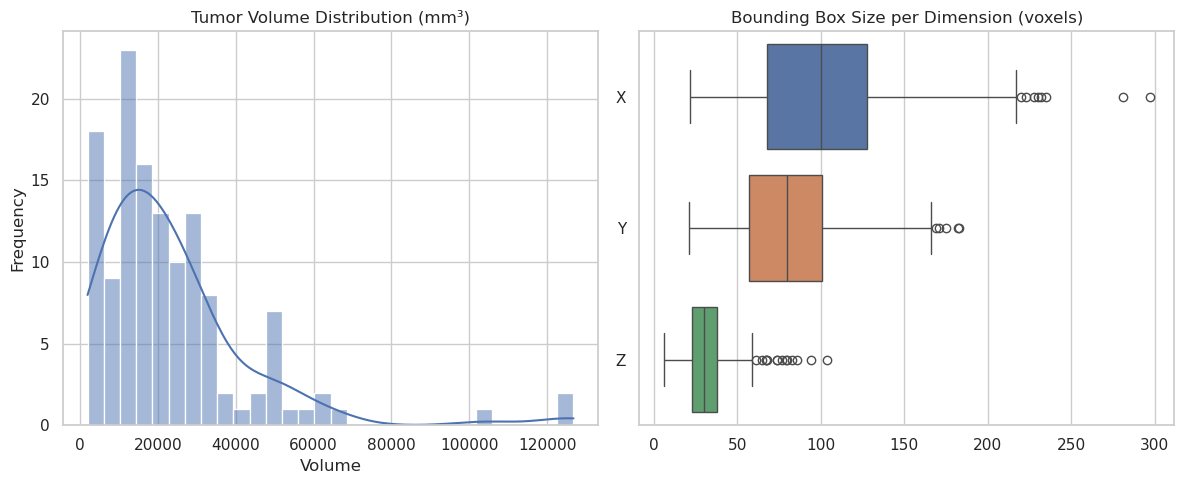


🔎 Number of patients analyzed: 130
📏 Mean tumor volume: 23347.15 mm³
📏 Median tumor volume: 17889.75 mm³
📏 Max tumor volume: 126770.65 mm³
📏 Min tumor volume: 1902.50 mm³


In [6]:
# Store volume statistics
volumes = []
nonzero_voxels = []
bbox_sizes = []

for p in tqdm(patients, desc="Analyzing patients"):
    mask_paths = glob.glob(os.path.join(p, "preRT", "*mask.nii.gz"))
    if len(mask_paths) != 1:
        print(f"⚠️ Skipping {p}: no unique mask found.")
        continue

    mask_img = nib.load(mask_paths[0])
    mask_data = mask_img.get_fdata()
    voxel_volume = np.prod(mask_img.header.get_zooms())

    # Binary mask (assuming tumor = 1)
    tumor_mask = (mask_data > 0).astype(np.uint8)
    tumor_voxels = np.sum(tumor_mask)

    if tumor_voxels == 0:
        continue

    volumes.append(tumor_voxels * voxel_volume)
    nonzero_voxels.append(tumor_voxels)

    # Bounding box dimensions
    coords = np.array(np.where(tumor_mask))
    mins = coords.min(axis=1)
    maxs = coords.max(axis=1)
    bbox = maxs - mins
    bbox_sizes.append(bbox)

# Convert to arrays
volumes = np.array(volumes)
nonzero_voxels = np.array(nonzero_voxels)
bbox_sizes = np.array(bbox_sizes)

# === Plots ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(volumes, bins=30, kde=True)
plt.title("Tumor Volume Distribution (mm³)")
plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(data=bbox_sizes, orient="h")
plt.yticks(ticks=[0, 1, 2], labels=["X", "Y", "Z"])
plt.title("Bounding Box Size per Dimension (voxels)")

plt.tight_layout()
plt.show()

# === 🧠 Summary stats ===
print(f"\n🔎 Number of patients analyzed: {len(volumes)}")
print(f"📏 Mean tumor volume: {volumes.mean():.2f} mm³")
print(f"📏 Median tumor volume: {np.median(volumes):.2f} mm³")
print(f"📏 Max tumor volume: {volumes.max():.2f} mm³")
print(f"📏 Min tumor volume: {volumes.min():.2f} mm³")


Analyzing 130 patients...


100%|█████████████████████████████████████████| 130/130 [01:56<00:00,  1.11it/s]


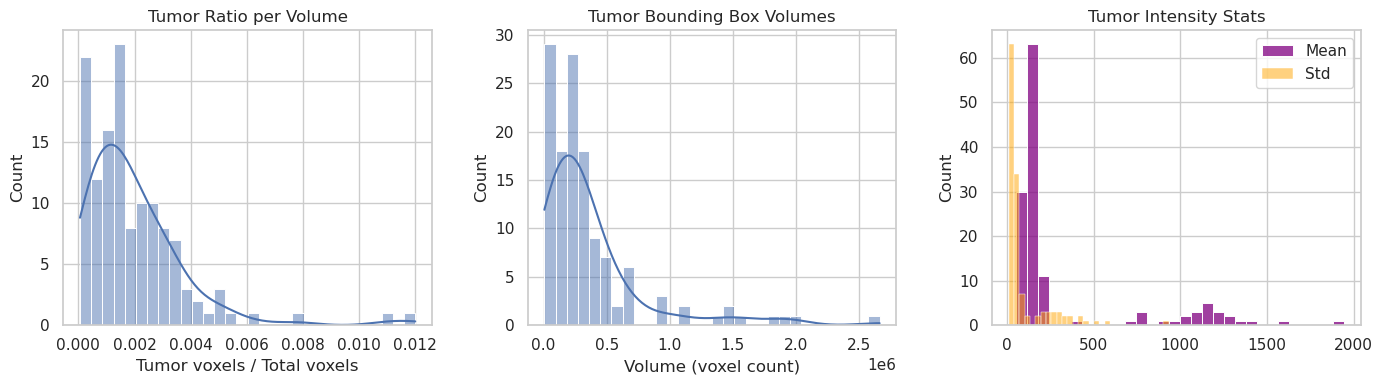


📊 Tumor presence in 130 out of 130 cases
⚖️ Mean tumor ratio: 0.0020 ± 0.0018
📦 Median bounding box size: 237655.50 voxels


In [7]:
tumor_voxels = []
background_voxels = []
tumor_ratios = []
bounding_boxes = []
intensity_means = []
intensity_stds = []
tumor_centers = []

print(f"Analyzing {len(patients)} patients...")
for p in tqdm(patients):
    t2_file = glob.glob(os.path.join(p, "preRT", "*T2.nii.gz"))
    mask_file = glob.glob(os.path.join(p, "preRT", "*mask.nii.gz"))
    if len(t2_file) != 1 or len(mask_file) != 1:
        continue

    t2_img = nib.load(t2_file[0]).get_fdata()
    mask = nib.load(mask_file[0]).get_fdata()

    # === Intensity statistics (non-background only)
    intensity_means.append(np.mean(t2_img[mask > 0]))
    intensity_stds.append(np.std(t2_img[mask > 0]))

    # === Tumor / background voxel counts
    tumor_count = np.sum(mask > 0)
    background_count = np.sum(mask == 0)
    total = tumor_count + background_count

    tumor_voxels.append(tumor_count)
    background_voxels.append(background_count)
    tumor_ratios.append(tumor_count / total)

    # === Bounding box size
    if tumor_count > 0:
        coords = np.argwhere(mask > 0)
        min_coords = coords.min(axis=0)
        max_coords = coords.max(axis=0)
        bbox = max_coords - min_coords
        bounding_boxes.append(bbox)

        # Tumor center
        labeled, _ = label(mask > 0)
        com = center_of_mass(mask, labeled)
        tumor_centers.append(com)

# === Visualization ===
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.histplot(tumor_ratios, bins=30, kde=True)
plt.title("Tumor Ratio per Volume")
plt.xlabel("Tumor voxels / Total voxels")

plt.subplot(1, 3, 2)
bbox_sizes = np.array([np.prod(b) for b in bounding_boxes])
sns.histplot(bbox_sizes, bins=30, kde=True)
plt.title("Tumor Bounding Box Volumes")
plt.xlabel("Volume (voxel count)")

plt.subplot(1, 3, 3)
sns.histplot(intensity_means, bins=30, color="purple", label="Mean")
sns.histplot(intensity_stds, bins=30, color="orange", label="Std", alpha=0.5)
plt.title("Tumor Intensity Stats")
plt.legend()

plt.tight_layout()
plt.show()

# === Summary ===
print(f"\n📊 Tumor presence in {np.sum(np.array(tumor_voxels) > 0)} out of {len(tumor_voxels)} cases")
print(f"⚖️ Mean tumor ratio: {np.mean(tumor_ratios):.4f} ± {np.std(tumor_ratios):.4f}")
print(f"📦 Median bounding box size: {np.median(bbox_sizes):.2f} voxels")
